In [91]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

RANDOM_STATE = 42

DATA_DIR = "./sp500"
CSV_PATH = os.path.join(DATA_DIR, "sp500_stocks.csv")

df = pd.read_csv(CSV_PATH)
print("shape:", df.shape)
df.head()

shape: (1891536, 8)


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
date_col = None
for c in ["Date"]:
    if c in df.columns:
        date_col = c
        break


ticker_col = None
for c in ["Symbol"]:
    if c in df.columns:
        ticker_col = c
        break

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values([ticker_col, date_col]).reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Date       datetime64[ns]
 1   Symbol     object        
 2   Adj Close  float64       
 3   Close      float64       
 4   High       float64       
 5   Low        float64       
 6   Open       float64       
 7   Volume     float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 115.5+ MB


In [93]:
print("Num of entries:", len(df))
print("Num of  Symbols:", df[ticker_col].nunique())
print("Dates:",
      df[date_col].min().date(), "->", df[date_col].max().date())


df.describe().T

Num of entries: 1891536
Num of  Symbols: 502
Dates: 2010-01-04 -> 2024-12-20


,count,mean,min,25%,50%,75%,max,std
Date,1891536,2017-06-27 13:11:27.898089472,2010-01-04 00:00:00,2013-09-30 18:00:00,2017-06-27 12:00:00,2021-03-25 06:00:00,2024-12-20 00:00:00,NaN
Adj Close,617831.0,79.672357,0.203593,26.572459,49.821613,94.831036,1702.530029,102.742931
Close,617831.0,87.47154,0.222,32.700001,59.139999,105.019997,1702.530029,104.521901
High,617831.0,88.417844,0.22625,33.060001,59.720001,106.129997,1714.75,105.684113
Low,617831.0,86.480997,0.21625,32.299999,58.5,103.889999,1696.900024,103.30077
Open,617831.0,87.460302,0.218,32.689999,59.119999,105.0,1706.400024,104.519845
Volume,617831.0,9347124.545253,0.0,1144000.0,2453400.0,5657850.0,3692928000.0,47716693.565471


In [94]:
available_tickers = df[ticker_col].unique()

target_ticker = "MSFT"


df_stock = df[df[ticker_col] == target_ticker].copy()
df_stock = df_stock.sort_values(date_col).reset_index(drop=True)

print("Chosen symbol:", target_ticker)
print("Shape:", df_stock.shape)
df_stock.head()

Chosen symbol: MSFT
Shape: (3768, 8)


,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MSFT,23.300684,30.950001,31.100000,30.590000,30.620001,38409100.0
1,2010-01-05,MSFT,23.308207,30.959999,31.100000,30.639999,30.850000,49749600.0
2,2010-01-06,MSFT,23.165167,30.770000,31.080000,30.520000,30.879999,58182400.0
3,2010-01-07,MSFT,22.924261,30.450001,30.700001,30.190001,30.629999,50559700.0
4,2010-01-08,MSFT,23.082355,30.660000,30.879999,30.240000,30.280001,51197400.0


In [95]:
price_col = None
for c in ["Adj Close"]:
    if c in df_stock.columns:
        price_col = c
        break

df_stock = df_stock[[date_col, price_col] + [c for c in df_stock.columns if c not in [date_col, price_col]]]
df_stock = df_stock.set_index(date_col)
df_stock.rename(columns={price_col: "price"}, inplace=True)
df_stock.head()

,price,Symbol,Close,High,Low,Open,Volume
Date,,,,,,,
2010-01-04,23.300684,MSFT,30.950001,31.100000,30.590000,30.620001,38409100.0
2010-01-05,23.308207,MSFT,30.959999,31.100000,30.639999,30.850000,49749600.0
2010-01-06,23.165167,MSFT,30.770000,31.080000,30.520000,30.879999,58182400.0
2010-01-07,22.924261,MSFT,30.450001,30.700001,30.190001,30.629999,50559700.0
2010-01-08,23.082355,MSFT,30.660000,30.879999,30.240000,30.280001,51197400.0


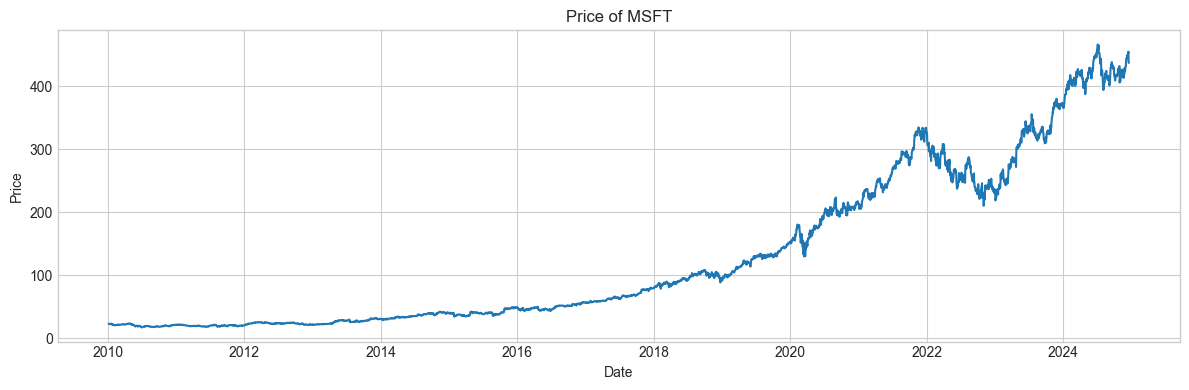

In [96]:
plt.figure(figsize=(12, 4))
plt.plot(df_stock.index, df_stock["price"])
plt.title(f"Price of {target_ticker}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

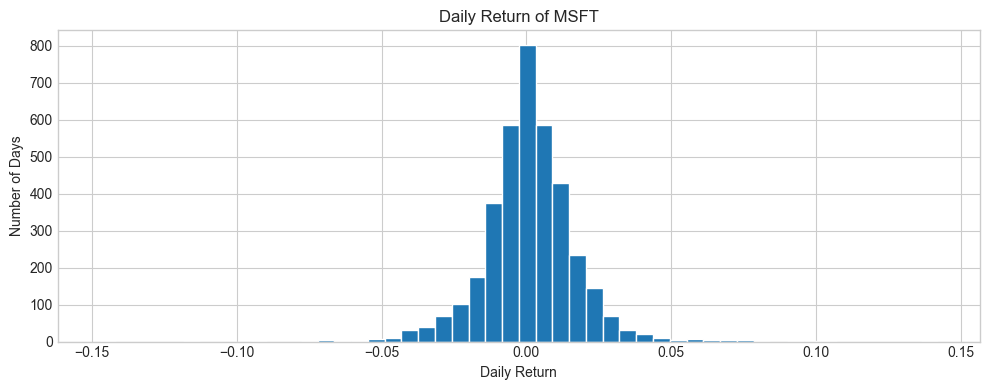

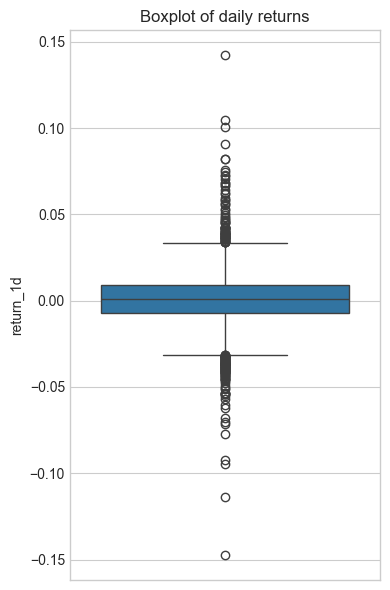

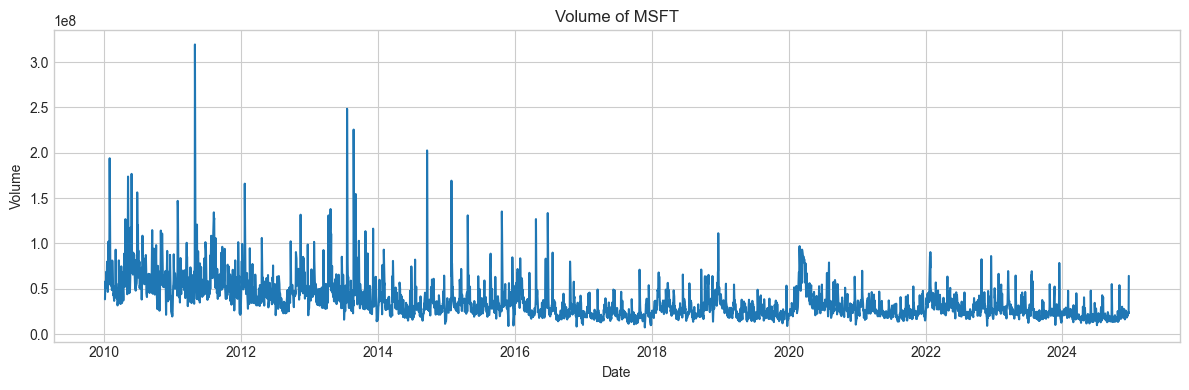

In [97]:
df_stock["return_1d"] = df_stock["price"].pct_change()

plt.figure(figsize=(10, 4))
df_stock["return_1d"].hist(bins=50)
plt.title(f"Daily Return of {target_ticker}")
plt.xlabel("Daily Return")
plt.ylabel("Number of Days")
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 6))
sns.boxplot(y=df_stock["return_1d"].dropna())
plt.title(f"Boxplot of daily returns")
plt.tight_layout()
plt.show()

In [98]:
df_stock["return_1d"] = df_stock["price"].pct_change(1)
df_stock["return_5d"] = df_stock["price"].pct_change(5)

df_stock["roll_mean_5"] = df_stock["price"].rolling(window=5).mean()
df_stock["roll_std_5"] = df_stock["price"].rolling(window=5).std()
df_stock["roll_mean_10"] = df_stock["price"].rolling(window=10).mean()
df_stock["roll_std_10"] = df_stock["price"].rolling(window=10).std()

df_stock["roll_vol_mean_5"] = df_stock["Volume"].rolling(window=5).mean()
df_stock["roll_vol_std_5"] = df_stock["Volume"].rolling(window=5).std()

df_stock.tail(10)

,price,Symbol,Close,High,Low,Open,Volume,return_1d,return_5d,roll_mean_5,roll_std_5,roll_mean_10,roll_std_10,roll_vol_mean_5,roll_vol_std_5
Date,,,,,,,,,,,,,,,
2024-12-09,446.019989,MSFT,446.019989,448.329987,440.500000,442.600006,19144400.0,0.005523,0.034897,440.166003,5.912020,432.504001,9.524368,20794920.0,3.195357e+06
2024-12-10,443.329987,MSFT,443.329987,449.619995,441.600006,444.390015,18469500.0,-0.006031,0.028131,442.591998,3.162375,434.957999,8.726267,20828420.0,3.163405e+06
2024-12-11,448.989990,MSFT,448.989990,450.350006,444.049988,444.049988,19200200.0,0.012767,0.026450,444.905994,2.617941,437.057999,9.366449,19466580.0,1.281019e+06
2024-12-12,449.559998,MSFT,449.559998,456.160004,449.109985,449.109985,20834800.0,0.001270,0.015679,446.293994,2.924709,439.714999,8.675430,19293980.0,9.095016e+05
2024-12-13,447.269989,MSFT,447.269989,451.429993,445.579987,448.440002,20177800.0,-0.005094,0.008341,447.033990,2.500509,442.095999,6.778469,19565340.0,9.351496e+05
2024-12-16,451.589996,MSFT,451.589996,452.179993,445.279999,447.269989,23598800.0,0.009659,0.012488,448.147992,3.103795,444.156998,6.124835,20456220.0,1.976189e+06
2024-12-17,454.459991,MSFT,454.459991,455.290009,449.570007,451.010010,22733500.0,0.006355,0.025105,450.373993,2.756218,446.482996,4.964183,21309020.0,1.818234e+06
2024-12-18,437.390015,MSFT,437.390015,452.649994,437.019989,451.320007,24444500.0,-0.037561,-0.025836,448.053998,6.521949,446.479996,4.970274,22357880.0,1.810213e+06
2024-12-19,437.029999,MSFT,437.029999,443.179993,436.320007,441.619995,22963700.0,-0.000823,-0.027872,445.547998,8.031246,445.920996,5.711690,22783660.0,1.600647e+06


In [99]:
df_stock["target_next_price"] = df_stock["price"].shift(-1)

feature_cols = [
    "price",
    "return_1d",
    "return_5d",
    "roll_mean_5",
    "roll_std_5",
    "roll_mean_10",
    "roll_std_10",
]

if "roll_vol_mean_5" in df_stock.columns:
    feature_cols += ["roll_vol_mean_5", "roll_vol_std_5"]

feature_cols = [c for c in feature_cols if c in df_stock.columns]

model_df = df_stock.dropna(subset=feature_cols + ["target_next_price"]).copy()
print("Num of rows after deleting NaN:", len(model_df))
model_df[feature_cols + ["target_next_price"]].head()

Num of rows after deleting NaN: 3758


,price,return_1d,return_5d,roll_mean_5,roll_std_5,roll_mean_10,roll_std_10,roll_vol_mean_5,roll_vol_std_5,target_next_price
Date,,,,,,,,,,
2010-01-15,23.232925,-0.003230,0.006523,22.963401,0.291939,23.059768,0.244288,65934320.0,1.010786e+07,23.413614
2010-01-19,23.413614,0.007777,0.027420,23.088375,0.329776,23.071061,0.258840,61498520.0,1.301053e+07,23.029657
2010-01-20,23.029657,-0.016399,0.017294,23.166674,0.226447,23.043206,0.245108,59286000.0,1.301297e+07,22.593002
2010-01-21,22.593002,-0.018961,-0.011202,23.115481,0.324102,22.985990,0.278043,63530640.0,1.344089e+07,21.802509
2010-01-22,21.802509,-0.034988,-0.064599,22.814342,0.642942,22.873814,0.467470,71285940.0,2.180631e+07,22.073532


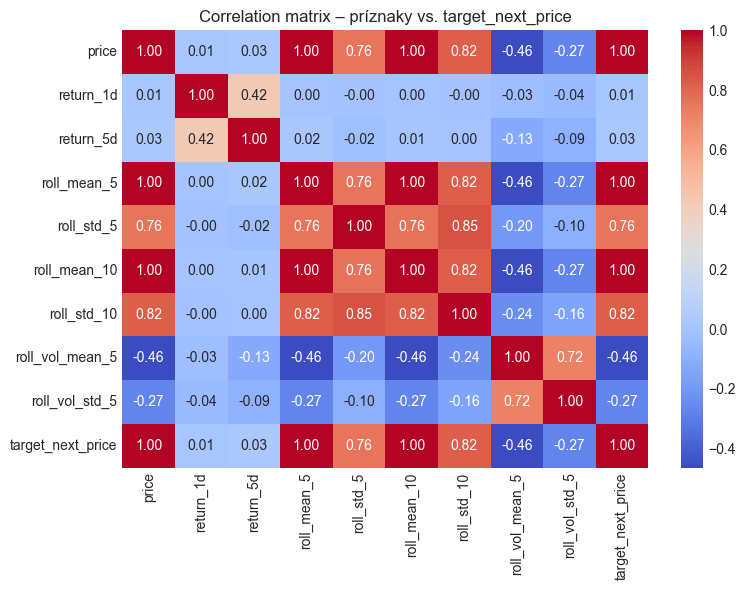

In [100]:
corr = model_df[feature_cols + ["target_next_price"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix – príznaky vs. target_next_price")
plt.tight_layout()
plt.show()


In [101]:
X = model_df[feature_cols].values
y = model_df["target_next_price"].values
dates = model_df.index

split_idx = int(len(model_df) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_train, dates_test = dates[:split_idx], dates[split_idx:]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 3006
Test size: 752


In [102]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

def print_metrics(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    mae_tr, rmse_tr, r2_tr = regression_metrics(y_true_train, y_pred_train)
    mae_te, rmse_te, r2_te = regression_metrics(y_true_test, y_pred_test)
    print(f"\nModel: {name}")
    print("  Train: MAE={:.4f}, RMSE={:.4f}, R^2={:.4f}".format(mae_tr, rmse_tr, r2_tr))
    print("  Test : MAE={:.4f}, RMSE={:.4f}, R^2={:.4f}".format(mae_te, rmse_te, r2_te))

In [104]:
models = {
    "LinearRegression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
}

results = []
tscv = TimeSeriesSplit(n_splits=5)

In [105]:
for name, est in models.items():
    model = clone(est)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    mae_tr, rmse_tr, r2_tr = regression_metrics(y_train, y_pred_train)
    mae_te, rmse_te, r2_te = regression_metrics(y_test, y_pred_test)

    cv_scores = cross_val_score(
        est,
        X,
        y,
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    print_metrics(name, y_train, y_pred_train, y_test, y_pred_test)
    print(f"  TimeSeriesSplit CV RMSE: mean={-cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

    results.append({
        "model": name,
        "train_MAE": mae_tr,
        "test_MAE": mae_te,
        "train_RMSE": rmse_tr,
        "test_RMSE": rmse_te,
        "train_R2": r2_tr,
        "test_R2": r2_te,
        "cv_RMSE_mean": -cv_scores.mean(),
        "cv_RMSE_std": cv_scores.std(),
    })

results_df = pd.DataFrame(results).sort_values("test_RMSE")
results_df


Model: LinearRegression
  Train: MAE=0.9295, RMSE=1.8039, R^2=0.9994
  Test : MAE=4.0746, RMSE=5.3140, R^2=0.9944
  TimeSeriesSplit CV RMSE: mean=2.4509, std=1.9977

Model: RandomForest
  Train: MAE=0.6317, RMSE=1.2505, R^2=0.9997
  Test : MAE=36.0089, RMSE=54.8193, R^2=0.4045
  TimeSeriesSplit CV RMSE: mean=44.1563, std=34.4754

Model: GradientBoosting
  Train: MAE=0.7468, RMSE=1.2508, R^2=0.9997
  Test : MAE=36.0655, RMSE=54.9584, R^2=0.4015
  TimeSeriesSplit CV RMSE: mean=44.2586, std=34.5518


,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,cv_RMSE_mean,cv_RMSE_std
0,LinearRegression,0.929457,4.074557,1.803923,5.313989,0.999422,0.994404,2.450946,1.997715
1,RandomForest,0.631693,36.008938,1.250458,54.819303,0.999722,0.404483,44.156326,34.475405
2,GradientBoosting,0.746796,36.065535,1.250807,54.958411,0.999722,0.401457,44.258579,34.551821


In [106]:
best_row = results_df.iloc[0]
best_name = best_row["model"]
print("Best model:", best_name)

best_est = models[best_name]
best_model = clone(best_est).fit(X_train, y_train)

y_pred_train_best = best_model.predict(X_train)
y_pred_test_best = best_model.predict(X_test)

Best model: LinearRegression


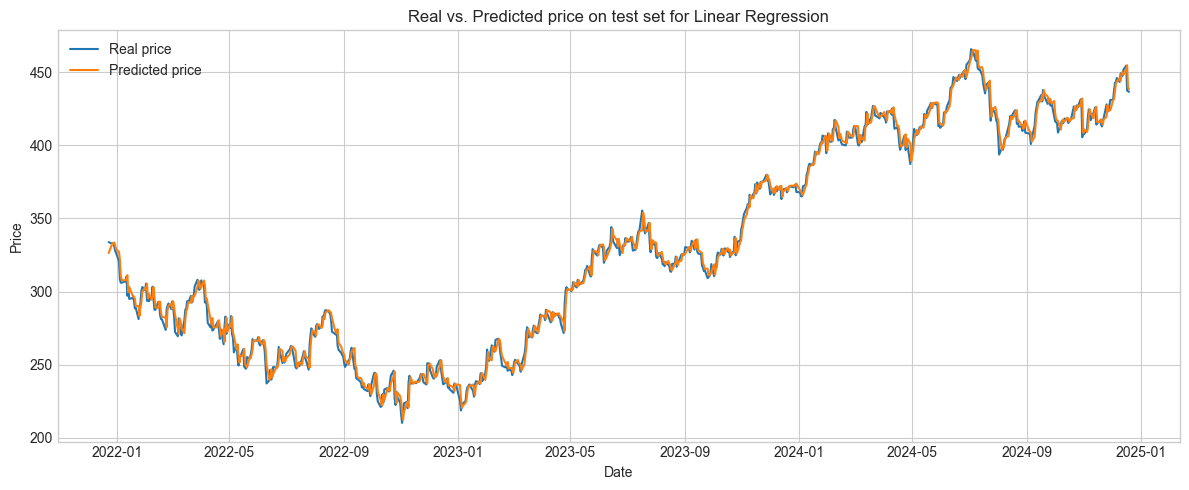

In [107]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test, label="Real price")
plt.plot(dates_test, y_pred_test_best, label=f"Predicted price")
plt.title(f"Real vs. Predicted price on test set for Linear Regression")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

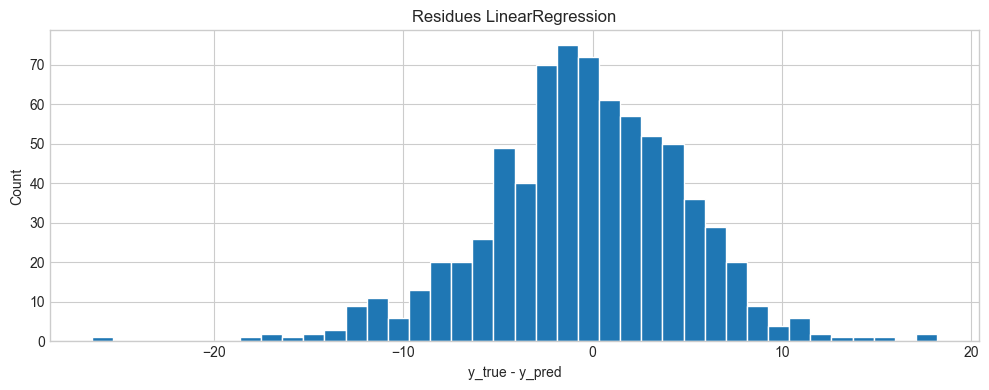

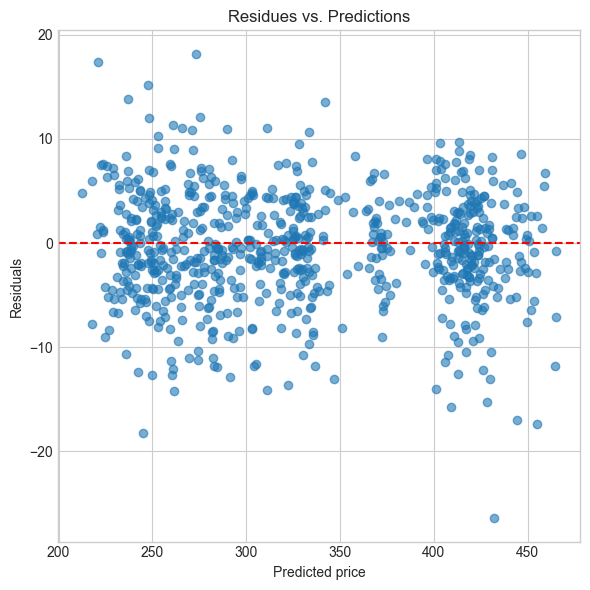

In [108]:
residuals = y_test - y_pred_test_best

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=40)
plt.title(f"Residues {best_name}")
plt.xlabel("y_true - y_pred")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_pred_test_best, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.title(f"Residues vs. Predictions")
plt.xlabel("Predicted price")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()